<a href="https://colab.research.google.com/github/DaeYejun2/ML_Notes/blob/main/ML_class5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 8. Neural Network Training (cont.) & Practical Advice for ML

## Multi-label Classification

일반적인 분류는 하나의 정답 레이블을 예측하지만, 멀티 레이블 분류는 하나의 입력에 여러 레이블이 동시에 붙을 수 있습니다. 자율주행차 예시에서 이미지 하나에 "차 있음", "버스 있음", "보행자 있음"을 동시에 판단하는 것이 대표적입니다.


단순하게 생각하면 레이블마다 별도의 뉴럴 네트워크를 만들 수 있지만(Naive Approach), 이는 비효율적입니다.

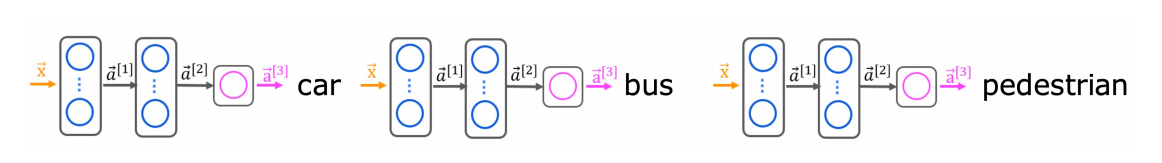


대신 출력층에 뉴런을 여러 개 두는 단일 네트워크 하나로 해결할 수 있습니다.

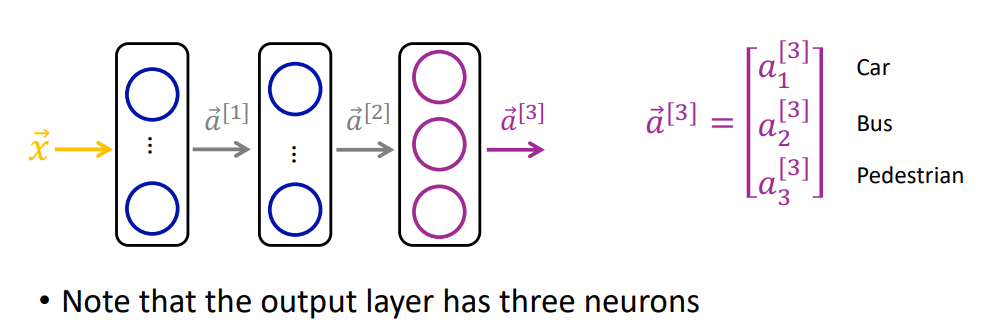

## Advanced Topics

Adam 옵티마이저가 핵심.

기본 경사하강법은 모든 파라미터에 동일한 학습률  α를 적용하지만, Adam은 파라미터마다 개별적으로 학습률을 자동 조정.

* 파라미터가 계속 같은 방향으로 움직이면 학습률 키우기.

* 진동하면 줄이는 방식.

실무에서 뭘 써야할지 모르겠으면 그냥 Adam 써라 ->
기존의 original 경사 하강법보다 빠름

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3), loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True))

### 레이어 측면(Dense Layer VS Convolutional Layer)

Dense Layer는 이전 레이어의 모든 출력을 입력으로 받는 반면, Convolutional Layer는 이전 레이어의 일부분만 본다.

그로인해 연산이 빠르고 적은 학습 데이터를 필요로해서 overfitting에도 강해짐.

Convolutional Neural Network는 컴퓨터 비전뿐만 아니라 EKG 신호 같은 시계열 데이터에서도 활용 됨

CNN의 다른 문제들 : 입력의 부분을 어떻게 볼 것인가, 레이어가 얼마나 많은 뉴런을 가져야 되나

## Back Propagation

역전파는 모델이 학습하는 핵심 알고리즘으로, TensorFlow 같은 프레임워크가 자동으로 처리해준다.

기본 개념은 편미분. W를 살짝 건드렸을 때 비용함수 J가 얼마나 변하는지를 나타내는 "배율"이 기울기이다.

기울기가 작으면 wj 업데이트도 작을 것이고, 기울기가 크면 wj 업데이트도 클 것이다.

w를 ε만큼 살짝 올렸을 때, J(w)가 k×ε만큼 변한다면 → 그 배율 k가 바로 미분값이다

$$∂w∂​J(w)=k $$

다시 설명하자면, w를 조건 건드렸을 때 J가 얼마나 크게 반응하는가의 민감도

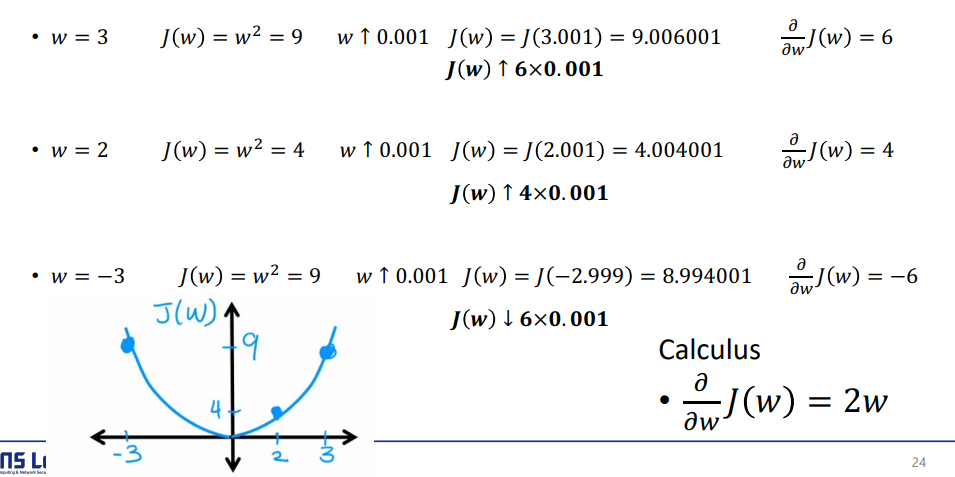



계산은 Computation Graph로 표현한다. 왼쪽→오른쪽 방향으로 진행하면 Forward Propagation, 오른쪽→왼쪽으로 거슬러 올라가며 각 파라미터의 편미분을 구하는 것이 Back Propagation

이때 연쇄법칙(Chain Rule)을 활용해 중간 계산 결과를 재사용하기 때문에, N개의 노드와 P개의 파라미터가 있을 때 N×P번이 아닌 N+P번 수준의 계산만으로 모든 기울기를 구할 수 있어 매우 효율적

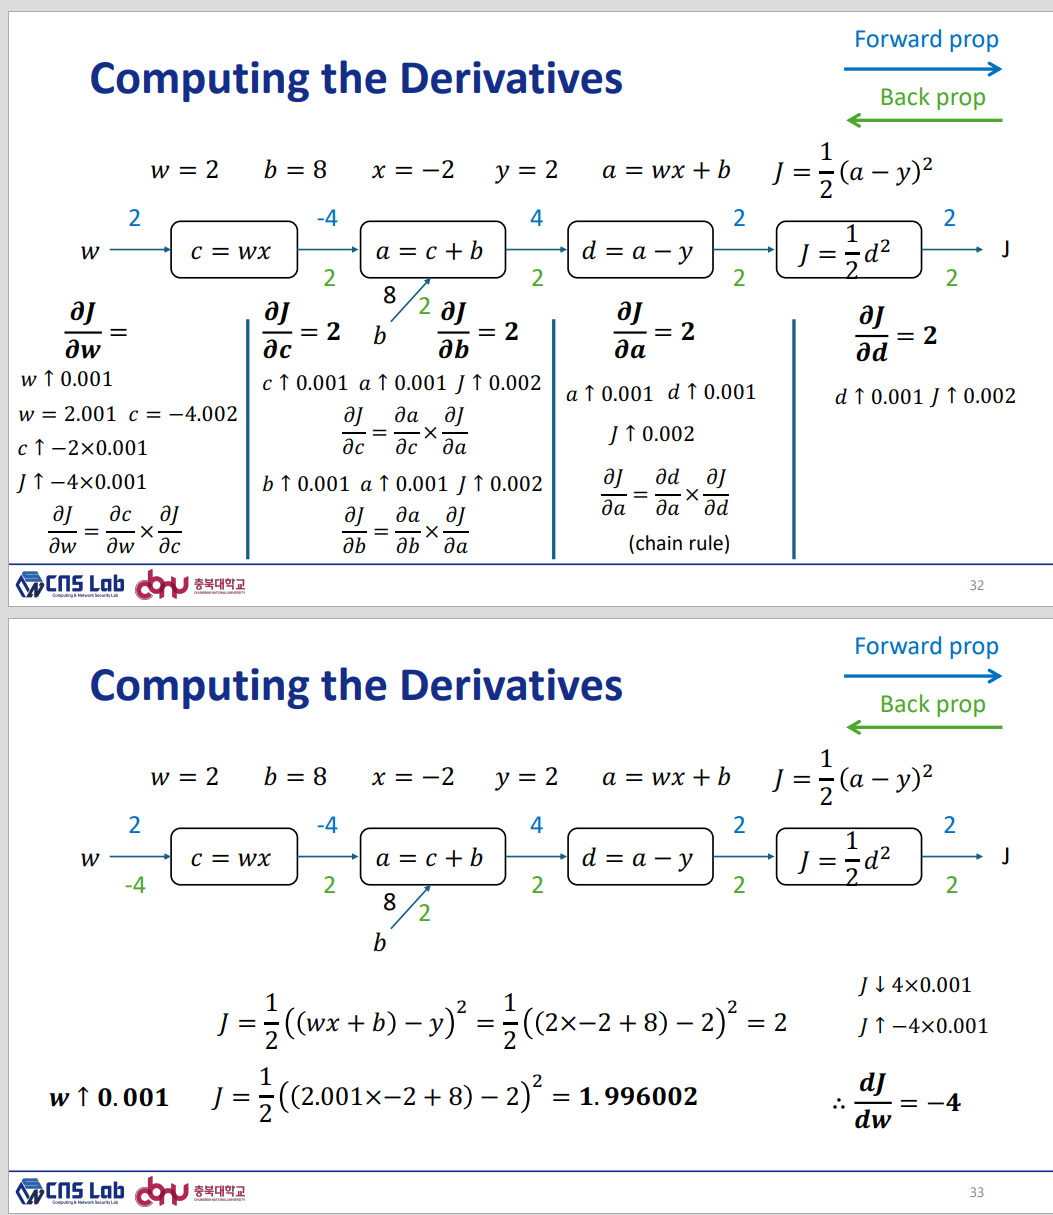

숫자 계산 시험 나올거 같은데;

Forward Propagation (왼쪽 → 오른쪽)

계산을 4단계 노드로 쪼개서 순서대로 진행한다.

c = wx = 2×(-2) = -4

a = c + b = -4 + 8 = 4

d = a - y = 4 - 2 = 2

J = ½d² = ½×4 = 2

Back Propagation (오른쪽 → 왼쪽)

이제 반대 방향으로 거슬러 올라가며 각 미분값을 구한다.

① 가장 오른쪽: ∂J/∂d

d를 0.001 올리면 → J가 0.002 증가
∴ ∂J/∂d = 2

② 한 칸 왼쪽: ∂J/∂a (연쇄법칙 적용)

a를 0.001 올리면 → d도 0.001 올라감 → J가 0.002 증가
∂J/∂a = (∂d/∂a) × (∂J/∂d) = 1 × 2 = 2

③ b와 c 노드: ∂J/∂b, ∂J/∂c

b 또는 c를 0.001 올리면 → a도 0.001 올라감 → J가 0.002 증가
∂J/∂b = (∂a/∂b) × (∂J/∂a) = 1 × 2 = 2
∂J/∂c = (∂a/∂c) × (∂J/∂a) = 1 × 2 = 2

④ 가장 왼쪽: ∂J/∂w (최종 목표)

w를 0.001 올리면 → c = wx이므로 c는 x배인 -2×0.001 변함
J는 -4×0.001 변함 (감소)
∂J/∂w = (∂c/∂w) × (∂J/∂c) = x × 2 = -4

실제로 w=2.001을 대입해보면

$$ J=21​((2.001×−2+8)−2)2=1.996002 $$

원래 J=2에서 0.003996 감소 → 약 -4×0.001과 일치

∴ dJ/dw = -4 확인 ✓

역전파는 오른쪽에서 한 번 구한 미분값(∂J/∂a)을 여러 곳 에서 재사용하기 때문에 계산을 N+P번으로 줄일 수 있어 매우 효율적이다.

### 예시
Forward Propagation

1층: a¹ = w¹x + b¹ = 2×1 + 0 = 2

2층: a² = w²a¹ + b² = 3×2 + 1 = 7

비용: J = ½(a² - y)² = ½(7-5)² = 2

w¹=2 → [t¹=w¹×x] →2→ [z¹=t¹+b¹] →2→ [a¹=g(z¹)] →2→
→ [t²=w²×a¹] →6→ [z²=t²+b²] →7→ [a²=g(z²)] →7→ [J=½(a²-y)²] → 2

결과: ∂J/∂w¹ = 6

w¹을 0.001 올려서 w¹=2.001로 바꾸면:

J가 원래 2에서 2.006005로 증가 → 약 6×0.001 증가

∴ ∂J/∂w¹ = 6 확인 ✓

## Advice for Applying ML

어떻게 디버깅, 평가, 개선해 나갈 것인지

모델 평가의 기본은 데이터를 Train / Test로 나누는 것.

훈련 오류는 낮은데 테스트 오류가 높으면 오버피팅 신호

Training examples 추가 확보, Features 집합 축소 또는 추가, 다항식 features 추가, 람다 조절

그런데 모델 선택 과정에서 테스트셋을 사용해버리면, 테스트 셋이 그 선택에 오염되어 실제 성능을 낙관적으로 추정

Train(60%) / Cross Validation(20%) / Test(20%) 세 가지로 나눕니다. (교차검증)CV셋으로 모델을 선택하고, 테스트셋은 최종 성능 평가에만 사용하는 것이 올바른 방식



Bias vs Variance 진단

모델의 문제를 정확히 파악하기 위해 훈련 오차와 교차 검증 오차를 비교

J_train 낮음 + J_test 높음 -> 오버피팅 (높은 분산)

J_train 높음 + J_test 높음 -> 언더피팅 (높은 편향)

다항식 차수를 테스트셋으로 고르면 테스트셋이 선택 과정에 오염되어 실제 성능보다 낙관적으로 평가

각 d에 대해 Training Set으로 학습

CV 오류(J_cv) 가 가장 낮은 d 선택

선택된 모델의 실제 성능은 Test Set으로 최종 평가

J_train → 낮음, J_cv   → 낮음 이 가장 이상적


### Train/Test Procedure
1. 선형회귀

선형 회귀는 수치(예: 집값)를 예측하는 모델입니다.  

 파라미터 학습: 훈련 데이터셋($m_{train}$)을 사용하여 비용 함수 $J(\vec{w}, b)$를 최소화하는 파라미터($\vec{w}, b$)를 찾습니다.   

 이때 모델의 복잡도를 제어하기 위해 규제 항($\frac{\lambda}{2m_{train}}\sum w_j^2$)을 포함하기도 합니다.   

 훈련 오차($J_{train}$) 계산: 학습된 파라미터를 사용하여 훈련 데이터에서의 평균 제곱 오차를 구합니다.   

 테스트 오차($J_{test}$) 계산: 학습에 사용되지 않은 테스트 데이터셋($m_{test}$)에 모델을 적용하여 오차를 계산합니다.  

  진단: 만약 $J_{train}$은 낮지만 $J_{test}$가 매우 높다면, 모델이 훈련 데이터에만 과하게 맞춰진(Overfitting) 상태임을 알 수 있습니다.   

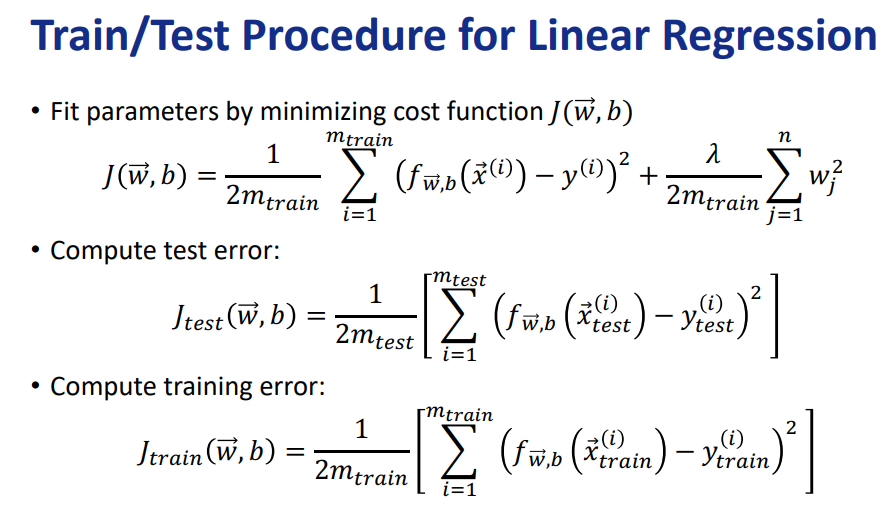


2. 분류 문제

분류 문제는 데이터가 특정 범주(예: 스팸 여부, 양성/음성)에 속하는지 판별합니다.   

파라미터 학습: 로지스틱 회귀 등에서 사용하는 비용 함수(Log Loss)를 최소화하여 $\vec{w}$와 $b$를 구합니다.   

오차 계산 ($J_{train}, J_{test}$): 선형 회귀와 마찬가지로 훈련 세트와 테스트 세트 각각에 대해 비용 함수의 값을 계산하여 모델의 성능을 확인합니다.   

실제 오분류율 측정 (Misclassification Error): 실제 현장에서는 비용 함수 값보다 "얼마나 많이 틀렸는가"를 더 자주 측정합니다.   예측값($f_{\vec{w},b}(\vec{x})$)이 $0.5$ 이상이면 $1$, 미만이면 $0$으로 분류합니다.   

오분류율: 전체 데이터 중 예측값($\hat{y}$)과 실제 정답($y$)이 일치하지 않는 데이터의 비율을 계산합니다.   

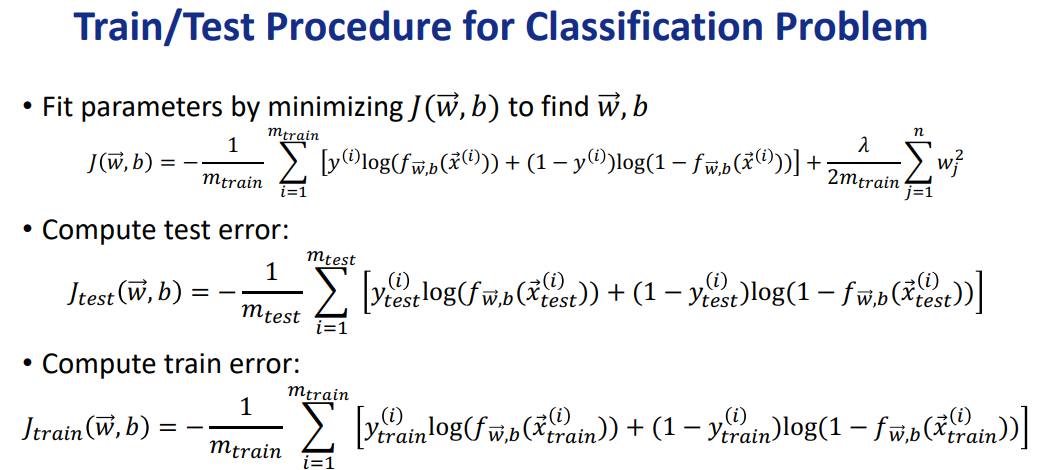


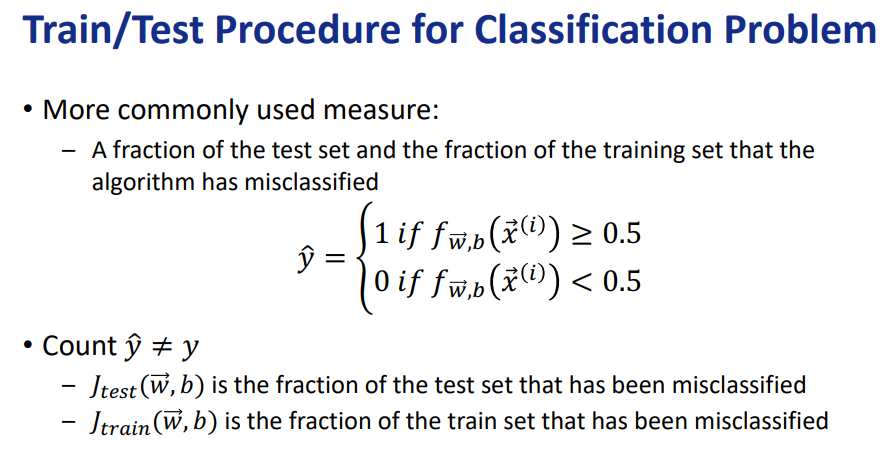

이미지에 나온 내용은 분류(Classification) 문제에서 모델이 "얼마나 틀렸는지"를 계산하는 방법입니다.   

* Count $\hat{y} \neq y$: 예측값($\hat{y}$)과 실제 정답($y$)이 다른 경우를 모두 세라는 의미입니다.   
* $J_{train}(\vec{w}, b)$: 훈련 세트(Train set) 데이터 중에서 모델이 잘못 분류한 데이터의 비율입니다.   
* $J_{test}(\vec{w}, b)$: 테스트 세트(Test set) 데이터 중에서 모델이 잘못 분류한 데이터의 비율입니다.

### Train/Test Procedure 프로세스

### ① 데이터 분리

```
전체 데이터
├── Train (70%)
└── Test  (30%)
```

---

### ② 학습

Train 데이터로 w, b 최적화
> 비용함수 J(w, b) 최소화

---

### ③ 오류 측정

| 구분 | 설명 |
|------|------|
| J_train | 훈련 오류 계산 |
| J_test  | 테스트 오류 계산 |

---

### ④ 진단

| J_train | J_test | 진단 결과 |
|---------|--------|----------|
| 낮음 | 높음 | ⚠️ 오버피팅 |
| 높음 | 높음 | ⚠️ 언더피팅 |
| 낮음 | 낮음 | ✅ 이상적 |

왜 Train/Test를 나누는가

만약 전체 데이터로만 학습하고 평가한다면?

모델이 데이터를 통째로 외워버려도
오류가 0으로 나옴 → 성능이 좋아 보임

하지만 실제 새 데이터에서는 엉망!

모델을 학습시키면 J_train은 항상 실제 성능보다 낙관적으로 나옵니다. 왜냐하면 모델이 훈련 데이터에 맞게 최적화됐기 때문입니다. 그래서 J_test가 실제 성능을 더 잘 반영합니다.

### 테스트셋으로 모델 선택하면 안 되는 이유
다항식 차수 d를 고를 때 이런 방법을 쓰면 안된다.

d=1  → J_test 계산

d=2  → J_test 계산

...

d=10 → J_test 계산

→ 가장 낮은 J_test의 d 선택  ← ❌ 잘못된 방법

d라는 추가 파라미터를 테스트셋으로 골랐기 때문에, 테스트셋이 이미 선택 과정에 오염된다. 그러면 J_test가 실제 성능보다 낙관적으로 나와 신뢰할 수 없게 된다.

그래서 올바른 방법이 Train(60%) / Cross Validation(20%) / Test(20%) 삼분할.

① 각 d마다 Train으로 학습

② J_cv가 가장 낮은 d 선택   ← CV셋으로 선택

③ 최종 성능은 J_test로 평가  ← Test셋은 딱 한 번만 - 이게 62p 코드인듯.

이렇게 하면 테스트셋이 오염되지 않아서 진짜 성능을 객관적으로 평가할 수 있다.

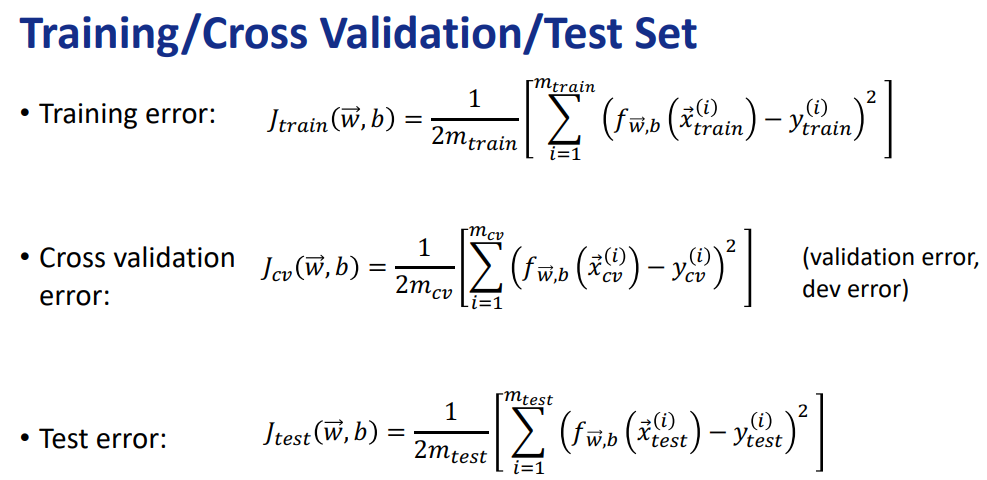

- Training/Cross Validation(=Dev Set)/Test Set
1. 모델을 선택할때 Cross Validation Set을 사용한다.
2. 왜 3개로 나누는지 (중요) : 학습용(Train) 데이터로 공부하고, 검증용(CV) 데이터로 모델의 최적 설정값(Hyperparameter)을 튜닝한 뒤, 마지막에 시험용(Test) 데이터로 모델의 진짜 실력을 객관적으로 평가하기 위해서

뉴럴 네워크 구조 선택에도 동일하게 적용한다. (63p)

구조1 (작은 네트워크) → J_cv 계산

구조2 (중간 네트워크) → J_cv 계산

구조3 (큰 네트워크)  → J_cv 계산

->

J_cv 가장 낮은 구조 선택

->

J_test로 최종 성능 평가

**Diagnosing Bias and Variance**

차수에 따른 J_train, J_cv 변화

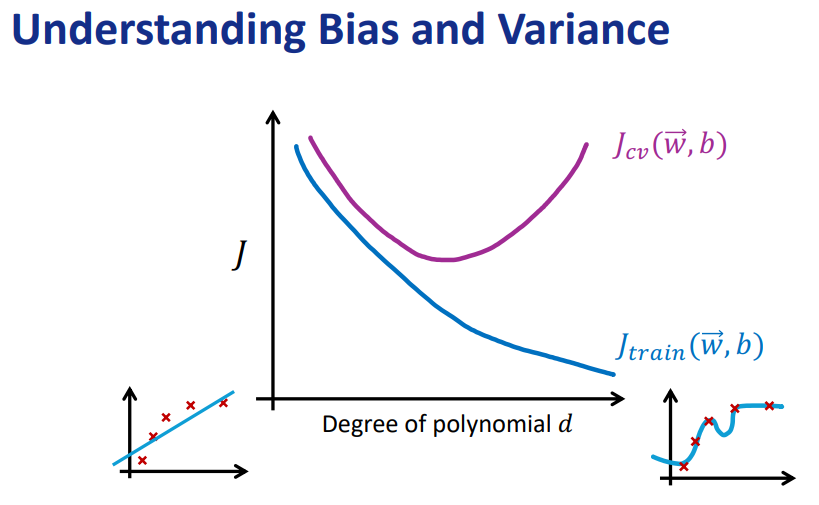

| 상태 | J_train | J_cv | 특징 |
|------|------| ------| ------|
| 고편향 | 높음 | 높음 | J_train ≈ J_cv |
| 이상적  | 낮음 | 낮음 | 둘다 낮음 |
| 고분산  | 낮음 | 높음 | J_cv >> J_train |

뉴럴 네트워크에서는 고편향 + 고분산이 동시에 나오는 경우가 있다

어떤 구간 → 오버피팅 (고분산)

다른 구간 → 언더피팅 (고편향)

이 둘이 동시에 → J_train 높음 + J_cv >> J_train

선형 모델에서는 발생하지 않고, 뉴럴 네트워크처럼 복잡한 모델에서만 나타난다.

모델 성능이 나쁨

  ↓

J_train 확인

        ├── 높음 → 고편향(언더피팅)
        │          → 모델 복잡도 높이기
        │          → 피처 추가
        │          → λ 줄이기
        │
        └── 낮음 → J_cv 확인
           ├── 높음 → 고분산(오버피팅)
           │          → 데이터 더 수집
           │          → 피처 줄이기
           │          → λ 늘리기
           │
           └── 낮음 → ✅ 이상적! 배포 가능



J_train 낮음 -> 훈련 데이터를 잘 맞춤, J_cv 낮음 -> 새로운 데이터도 잘 맞춘다는 뜻

* J_train 낮음 + J_cv 높음
  * 훈련 데이터는 잘 맞추는데, 새 데이터는 못 맞춤
  * 훈련 데이터를 그냥 외워버린 것 = 오버피팅 ⚠️

* J_train 높음 + J_cv 높음
  * 훈련 데이터도 못 맞추고, 새 데이터도 못 맞춤
  * 모델 자체가 너무 단순한 것 = 언더피팅 ⚠️
